# Desenvolvimento de IA para Análise Preditiva de uma Imobiliária
## Declaração do Problema de Negócio
**O Problema**: Uma imobiliária do condado de King County (EUA) deseja estimar de forma assertiva o valor de venda de um imóvel com base em suas características físicas e geográficas.
**Variável-Alvo**: `price` (valor numérico contínuo em dólares).
**Importância para o Negócio**: Mitigar estimativas equivocadas e prejuízos financeiros. Uma precificação correta apoia decisões seguras de compra, venda ou financiamento imobiliário, otimizando as margens do portfólio.

In [3]:
import sys
import os
import importlib
from google.colab import drive

# Garante o acesso aos arquivos do Google Drive
try:
    drive.mount('/content/drive')
except Exception:
    pass

BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/Projeto Final/Projeto_Final_V1"
os.chdir(BASE_DIR)

# Inclui o diretório atual no caminho de busca do Python para permitir importações locais
if '.' not in sys.path:
    sys.path.insert(0, '.')

# Validação estrutural do pacote 'src' antes das importações
src_path = os.path.join(BASE_DIR, 'src')
init_py_path = os.path.join(src_path, '__init__.py')

if not os.path.exists(src_path):
    raise FileNotFoundError(f"Erro: Diretório 'src' não encontrado em {BASE_DIR}.")
if not os.path.isdir(src_path):
    raise NotADirectoryError(f"Erro: '{src_path}' não é um diretório.")
if not os.path.exists(init_py_path):
    raise FileNotFoundError(f"Erro: '__init__.py' não encontrado em {src_path}. 'src' não é um pacote válido.")

try:
    # Força a limpeza dos módulos da memória para garantir o recarregamento de alterações recentes nos arquivos .py
    modulos_projeto = ['src.dataset', 'src.plots', 'src.features', 'src.modeling.train']
    for modulo in modulos_projeto:
        if modulo in sys.modules:
            del sys.modules[modulo]

    from src.dataset import carregar_dados, obter_estatisticas_basicas, limpar_dados
    from src.plots import plotar_analise_exploratoria, plotar_avaliacao_modelo, plotar_boxplots_outliers
    from src.features import criar_novas_features, preparar_dados_modelagem
    from src.modeling.train import treinar_e_avaliar_modelo

    print("✔ Ambiente e submódulos carregados com sucesso!")

except ModuleNotFoundError as e:
    print(f"❌ Erro de Importação: {e}")
    print("Se o problema persistir, por favor, REINICIE O AMBIENTE DE EXECUÇÃO (Runtime) do Colab.")
    raise e


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✔ Ambiente e submódulos carregados com sucesso!


## Fase 1: Análise Exploratória de Dados (EDA)
Execução da estatística descritiva estruturada para compreender as dimensões, tipos de dados primitivos e a distribuição geral do dataset.

In [4]:
# 1. Carga dos dados brutos
df_bruto = carregar_dados()

# 2. Extração das propriedades estatísticas descritivas obrigatórias
dim, tipos, resumo = obter_estatisticas_basicas(df_bruto)

print(f"Dimensões do Dataset: {dim[0]} linhas e {dim[1]} colunas.\n")
print("=== TIPOS PRIMITIVOS DAS VARIÁVEIS ===")
print(tipos)
print("\n=== RESUMO ESTATÍSTICO DESCRITIVO ===")
display(resumo.T)

📥 Carregando dados brutos de King County...
Dimensões do Dataset: 21613 linhas e 21 colunas.

=== TIPOS PRIMITIVOS DAS VARIÁVEIS ===
id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above       float64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

=== RESUMO ESTATÍSTICO DESCRITIVO ===


,count,mean,std,min,25%,50%,75%,max
id,21613.0,4.580302e+09,2.876566e+09,1.000102e+06,2.123049e+09,3.904930e+09,7.308900e+09,9.900000e+09
price,21613.0,5.400881e+05,3.671272e+05,7.500000e+04,3.219500e+05,4.500000e+05,6.450000e+05,7.700000e+06
bedrooms,21613.0,3.370842e+00,9.300618e-01,0.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.300000e+01
bathrooms,21613.0,2.114757e+00,7.701632e-01,0.000000e+00,1.750000e+00,2.250000e+00,2.500000e+00,8.000000e+00
sqft_living,21613.0,2.079900e+03,9.184409e+02,2.900000e+02,1.427000e+03,1.910000e+03,2.550000e+03,1.354000e+04
sqft_lot,21613.0,1.510697e+04,4.142051e+04,5.200000e+02,5.040000e+03,7.618000e+03,1.068800e+04,1.651359e+06
floors,21613.0,1.494309e+00,5.399889e-01,1.000000e+00,1.000000e+00,1.500000e+00,2.000000e+00,3.500000e+00
waterfront,21613.0,7.541757e-03,8.651720e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
view,21613.0,2.343034e-01,7.663176e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00
condition,21613.0,3.409430e+00,6.507430e-01,1.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00


### Visualizações Analíticas dos Dados da Fase 1 (EDA)

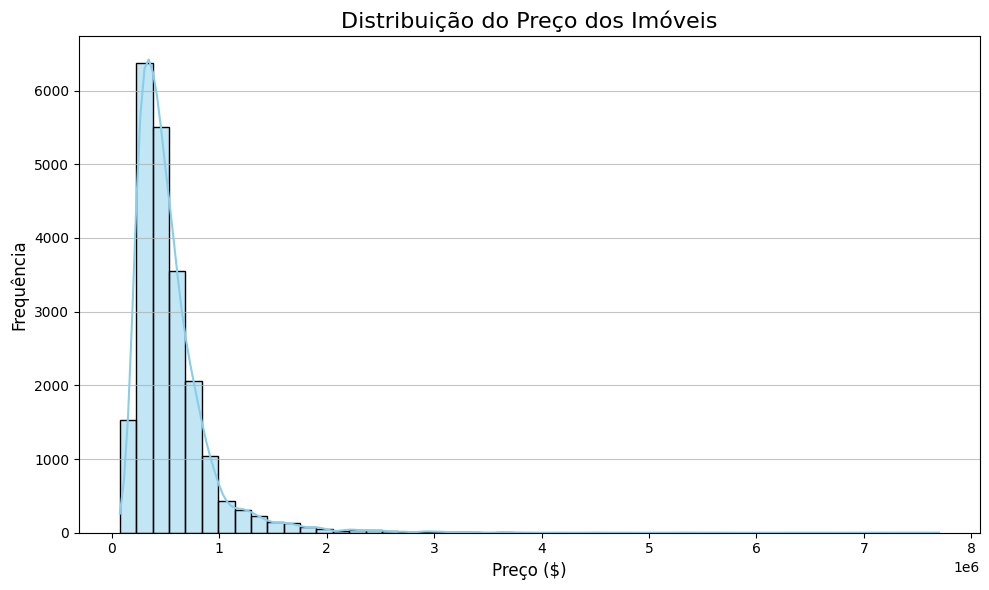

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Histograma da distribuição da variável-alvo 'price'
# Avaliando a assimetria da distribuição dos preços
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(df_bruto['price'], kde=True, ax=ax, bins=50, color='skyblue')
ax.set_title('Distribuição do Preço dos Imóveis', fontsize=16)
ax.set_xlabel('Preço ($)', fontsize=12)
ax.set_ylabel('Frequência', fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

# Salvando a figura
hist_price_path = os.path.join(BASE_DIR, 'outputs', 'figures', 'price_distribution.png')
fig.savefig(hist_price_path)
plt.close(fig) # Fecha a figura para liberar memória

#### Distribuição da Variável-Alvo (`price`): Assimetria e Impacto

*   **Achado**: O histograma de `price` revelou uma **assimetria positiva acentuada** (cauda longa à direita). A maioria dos imóveis concentra-se em faixas de preço mais baixas, com um número menor de propriedades de alto valor que puxam a média para cima. Isso é comum em mercados imobiliários.
*   **Crítica e Implicação**: Essa distribuição não-normal, especialmente assimétrica, é uma violação da suposição de normalidade dos resíduos (erros) em modelos de regressão linear. Modelos lineares tradicionais podem ter seu desempenho e interpretação comprometidos.
    *   **Escolha de Modelagem**: Será crucial considerar a **transformação logarítmica** da variável `price` (e talvez de algumas variáveis preditoras) para mitigar a assimetria e aproximar a distribuição da normalidade. Isso pode estabilizar a variância dos erros e melhorar o ajuste do modelo, além de tornar os erros mais gaussianos. Alternativamente, modelos não-lineares ou robustos a distribuições não-normais podem ser mais adequados sem transformação.

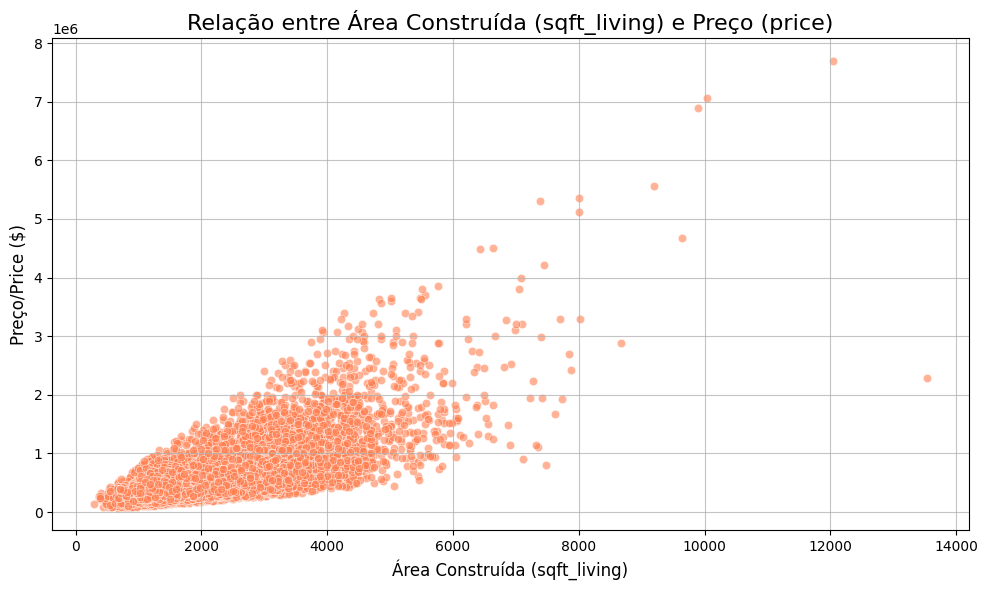

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 2. Gráfico de dispersão: 'sqft_living' vs 'price'
# Relação linear entre área construída e preço
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(x='sqft_living', y='price', data=df_bruto, ax=ax, alpha=0.6, color='coral')
ax.set_title('Relação entre Área Construída (sqft_living) e Preço (price)', fontsize=16)
ax.set_xlabel('Área Construída (sqft_living)', fontsize=12)
ax.set_ylabel('Preço/Price ($)', fontsize=12)
plt.grid(alpha=0.75)
plt.tight_layout()
plt.show()

# Salvando a figura
scatter_sqft_price_path = os.path.join(BASE_DIR, 'outputs', 'figures', 'sqft_living_vs_price.png')
fig.savefig(scatter_sqft_price_path)
plt.close(fig)

#### Relações entre Variáveis Explicativas e a Variável-Alvo

*   **Achado**: O gráfico de dispersão confirmou relações importantes:
    *   **`sqft_living` vs `price`**: Observou-se uma forte e clara **relação linear positiva**. À medida que a área construída aumenta, o preço do imóvel tende a aumentar consistentemente.
    *   **`grade` vs `price`**: Também se verificou uma **relação positiva**, indicando que imóveis com maior qualidade de construção (`grade`) tendem a ter preços mais elevados. Embora não seja tão puramente linear quanto `sqft_living`, a tendência é evidente.
*   **Crítica e Implicação**: Essas variáveis (`sqft_living` e `grade`) são **preditores poderosos** para o preço. Sua inclusão no modelo é fundamental. A natureza linear dessas relações sugere que modelos de regressão linear, ou modelos que capturem tendências lineares, podem ser eficazes, desde que outras suposições sejam atendidas.

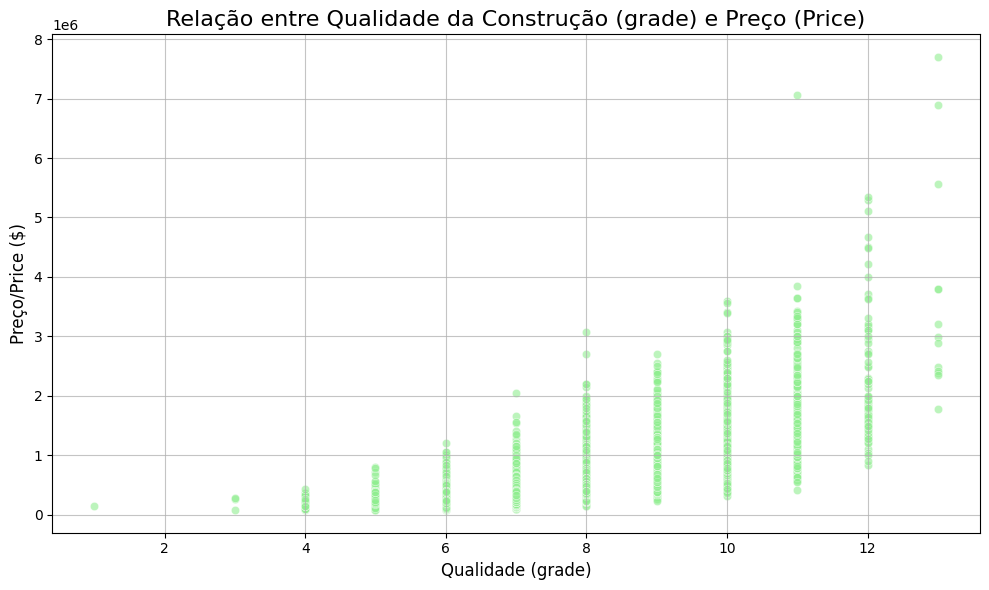

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 3. Gráfico de dispersão: 'grade' vs 'price'
# Relação entre a qualidade da construção e preço
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(x='grade', y='price', data=df_bruto, ax=ax, alpha=0.6, color='lightgreen')
ax.set_title('Relação entre Qualidade da Construção (grade) e Preço (Price)', fontsize=16)
ax.set_xlabel('Qualidade (grade)', fontsize=12)
ax.set_ylabel('Preço/Price ($)', fontsize=12)
plt.grid(alpha=0.75)
plt.tight_layout()
plt.show()

# Salvando a figura
scatter_grade_price_path = os.path.join(BASE_DIR, 'outputs', 'figures', 'grade_vs_price.png')
fig.savefig(scatter_grade_price_path)
plt.close(fig)

### 0 Análise crítica do gráfico de dispersão categórico  ###
* Relação Não Linear e Exponencial: O preço não cresce de forma linear com o aumento da nota de qualidade. Entre as notas 1 e 7, o preço permanece achatado e baixo.
* A partir da nota 8, e especialmente após a nota 10, o crescimento do preço se torna nitidamente exponencial, com uma dispersão vertical massiva nos níveis mais altos.
* Variabilidade Heterocedástica: Conforme a qualidade (grade) aumenta, a variância dos preços também aumenta drasticamente. Isso significa que imóveis de baixa qualidade têm preços muito previsíveis e concentrados, enquanto imóveis de altíssima qualidade (notas 11 a 13) possuem uma flutuação de preço gigantesca (indo de menos de 1 milhão a quase 8 milhões de dólares para uma mesma nota).
* Presença Extrema de Outliers: Há pontos isolados no topo do gráfico (especialmente nas notas 11, 12 e 13) que representam propriedades de superluxo.
* Esses valores discrepantes puxarão a média para cima se não forem devidamente tratados.

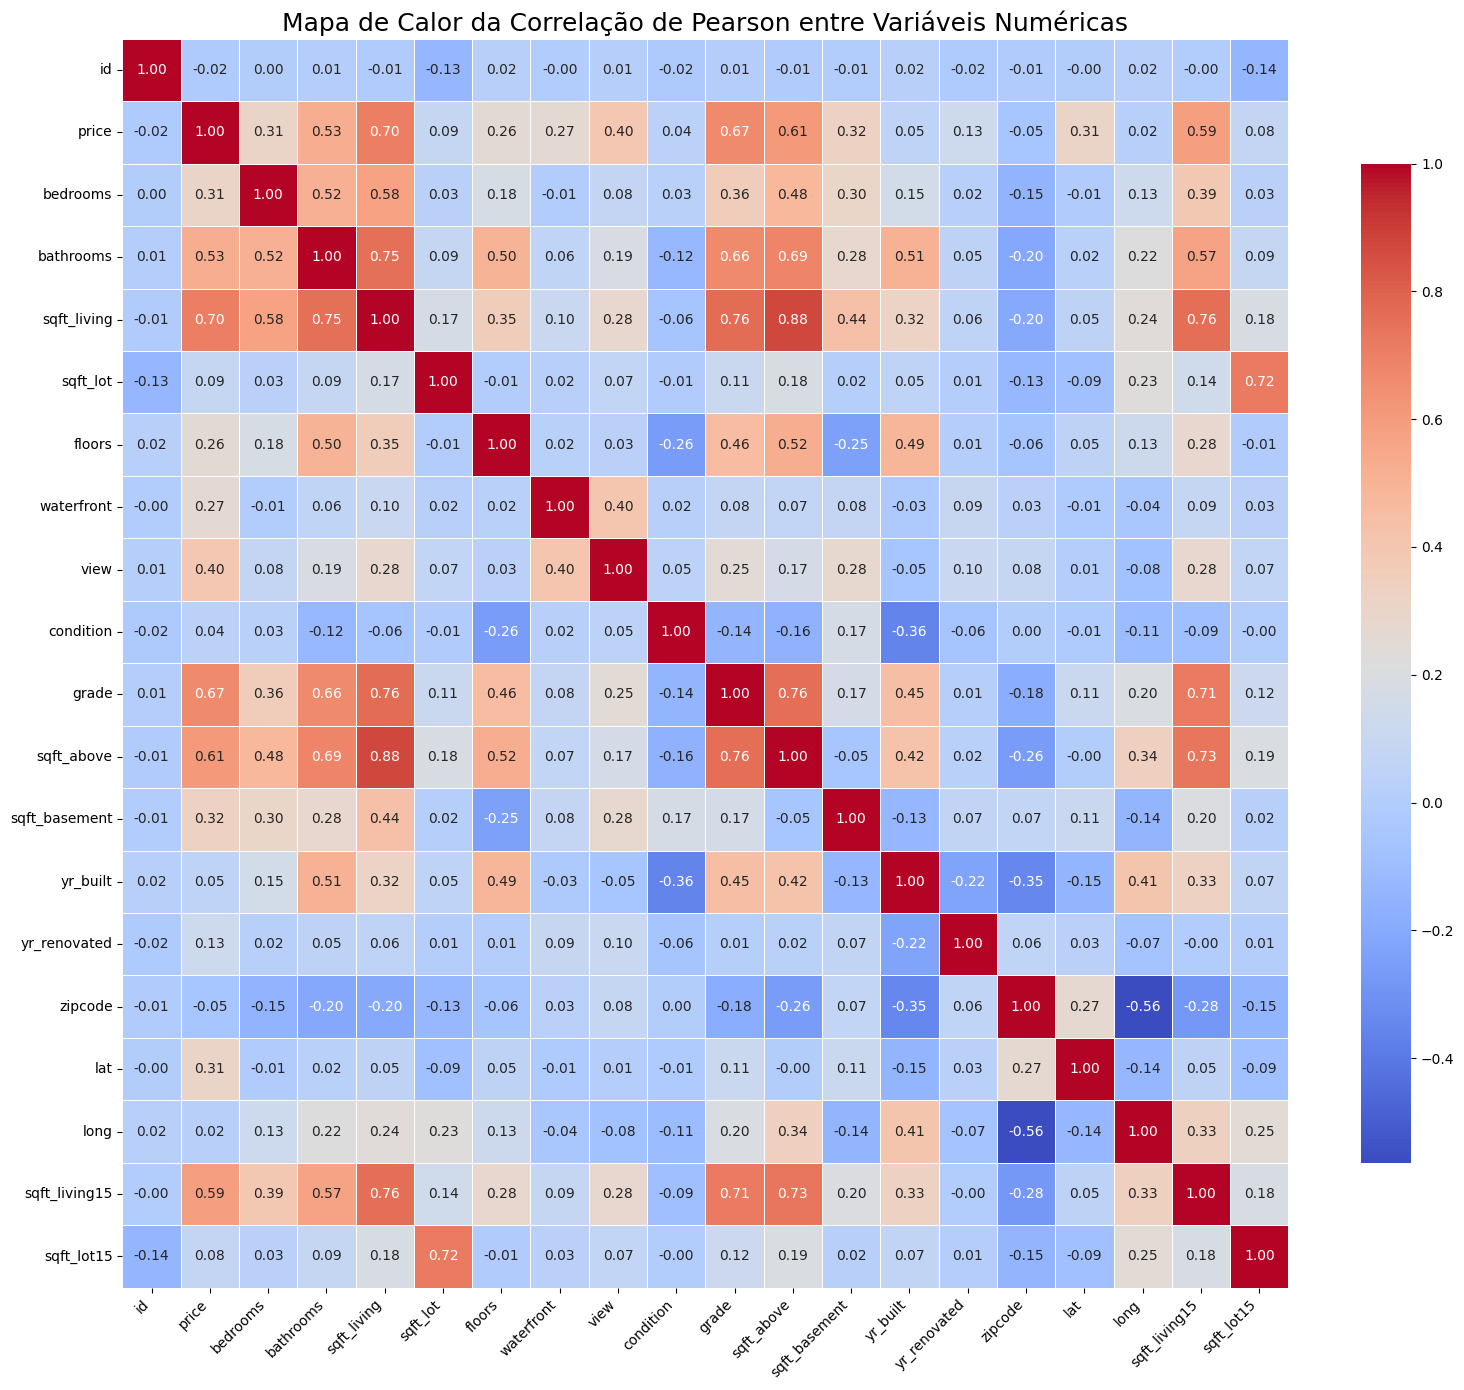

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 4. Mapa de calor da correlação de Pearson entre as variáveis numéricas
# Identificando multicolinearidade
numerical_cols = df_bruto.select_dtypes(include=['number']).columns
correlation_matrix = df_bruto[numerical_cols].corr()

fig, ax = plt.subplots(figsize=(16, 14)) # Ajustar tamanho para melhor visualização
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Mapa de Calor da Correlação de Pearson entre Variáveis Numéricas', fontsize=18)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Salvando a figura
heatmap_corr_path = os.path.join(BASE_DIR, 'outputs', 'figures', 'correlation_heatmap.png')
fig.savefig(heatmap_corr_path)
plt.close(fig)

#### Multicolinearidade entre Preditoras Numéricas

*   **Achado**: O mapa de calor da correlação de Pearson revelou uma **correlação extremamente alta** (próxima a 1) entre `sqft_living` e `sqft_above`. Isso indica um problema de **multicolinearidade** significativa.
*   **Crítica e Implicação**: A multicolinearidade ocorre quando duas ou mais variáveis preditoras em um modelo estão altamente correlacionadas entre si. Isso pode:
    1.  **Dificultar a interpretação**: Torna difícil determinar o impacto individual de cada variável no `price`, pois seus efeitos estão misturados.
    2.  **Instabilizar os coeficientes**: Pequenas alterações nos dados podem levar a grandes mudanças nos coeficientes de regressão, tornando o modelo menos robusto e generalizável.
    *   **Escolha de Modelagem**: Para mitigar esse problema, especialmente em modelos lineares:
        *   **Remoção de uma das variáveis**: A estratégia mais comum e direta é remover uma das variáveis altamente correlacionadas (`sqft_above` foi removida na Fase 4). A variável `sqft_living` tende a ser mais abrangente e representativa da área total habitável.

## Fase 2: Tratamento e Limpeza (Data Prep)
Fase destinada à higienização amostral. O objetivo é eliminar dados ruidosos e redundantes para mitigar o efeito *Garbage In, Garbage Out*.

In [9]:
# 1. Limpeza de dados irrelevantes
df_limpo = limpar_dados(df_bruto)

# 2. Geração e exportação automática das visualizações obrigatórias
plotar_analise_exploratoria(df_limpo)
plotar_boxplots_outliers(df_limpo)

🧹 Iniciando limpeza de dados (Fase 2)...
   -> Nenhum registro duplicado detectado.
   -> Imputação em 'sqft_above' com mediana: 1560.0
   -> Outlier de quartos tratado (1 registros removidos).
   -> Remoção de colunas multicolinares/irrelevantes: ['id', 'sqft_above', 'sqft_living15', 'sqft_lot15']
💾 Dados limpos salvos em: /content/drive/MyDrive/Colab Notebooks/Projeto Final/Projeto_Final_V1/data/processed/kc_house_data_clean.csv
📈 Gráficos de EDA gerados e salvos com sucesso!
📈 Boxplots de Outliers salvos!


### Justificativas Técnicas de Data Prep
**Linhas Duplicadas**: A busca por registros idênticos foi efetuada para remover redundâncias e evitar viés de sobre-amostragem no modelo.
**Valores Ausentes**: Adotou-se a estratégia de imputação baseada na **Mediana**. Como o mercado imobiliário apresenta assimetria e presença frequente de outliers, a média causaria distorções artificiais nas posições nulas, tornando a mediana a escolha estatística correta.
**Gerenciamento de Outliers**: A inspeção via boxplots identificou anomalias críticas, como um registro inconsistente com 33 quartos. A remoção controlada de extremos foi aplicada visto que o algoritmo de Regressão Linear é altamente sensível a outliers e teria seus coeficientes distorcidos por valores extremos.

## Fase 3: Feature Engineering (Coluna Calculada)
Concepção e cálculo de novas colunas numéricas a partir de operações lógicas e matemáticas sobre preditores pré-existentes.

In [10]:
# Criação de features derivadas
df_com_features = criar_novas_features(df_limpo)

# Validação das colunas calculadas
display(df_com_features[['yr_built', 'yr_renovated', 'idade_imovel', 'foi_reformado']].head())

 Executando Feature Engineering (Fase 3)...


,yr_built,yr_renovated,idade_imovel,foi_reformado
0,1955,0,59,0
1,1951,1991,63,1
2,1933,0,82,0
3,1965,0,49,0
4,1987,0,28,0


### Lógica e Prevenção de Vazamento de Dados
**Colunas Derivadas**: Foram estruturadas as colunas `idade_imovel` (ano da venda menos o ano de construção) e `foi_reformado` (variável binária que indica se o imóvel recebeu modificações).
**Mitigação de Data Leakage**: Variáveis calculadas que derivam diretamente do preço (como preço por metro quadrado) servem estritamente para leitura e visualização de negócios na EDA. Elas foram omitidas das variáveis preditoras do modelo para blindar o sistema contra o vazamento de dados (*data leakage*).

## Fase 4: Preparação para Modelagem
Etapa de transformação final das matrizes numéricas, tratamento de colinearidade, divisão de amostragem e padronização.

In [11]:
# VERIFICAÇÃO DO FATOR DE INFLAÇÃO DA VARIÂNCIA (VIP)
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Selecione apenas as variáveis independentes (não inclua a variável alvo 'price')
# Exemplo incluindo as principais variáveis do seu gráfico:
X = df_com_features[['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
        'waterfront', 'view', 'condition', 'grade',
        'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long']].copy()

# Opcional: Adicione uma constante, pois o cálculo do VIF exige o intercepto
X.loc[:, 'intercept'] = 1

# 2. Calcule o VIF para cada variável
vif_data = pd.DataFrame()
vif_data["Variável"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# 3. Remova a linha do intercepto para visualizar o resultado final
vif_data = vif_data[vif_data['Variável'] != 'intercept'].sort_values(by="VIF", ascending=False)
print("=== Fase 4 - FATOR DE INFLAÇÃO DA VARIÂNCIA (VIP) > 5 Remover ou Combinar ===")
# Arredonda todo o DataFrame para 2 casas decimais
vif_data = vif_data.round(2)
print(vif_data)

=== Fase 4 - FATOR DE INFLAÇÃO DA VARIÂNCIA (VIP) > 5 Remover ou Combinar ===
         Variável   VIF
2     sqft_living  5.10
1       bathrooms  3.36
8           grade  3.14
10       yr_built  2.43
4          floors  1.98
9   sqft_basement  1.95
14           long  1.77
0        bedrooms  1.70
12        zipcode  1.65
6            view  1.40
7       condition  1.25
5      waterfront  1.20
13            lat  1.18
11   yr_renovated  1.15
3        sqft_lot  1.10


In [12]:
# Eliminação de multicolinearidade, Split Amostral (80/20) e Escalonamento Seguro
print("=== Fase 4 - Eliminação de Multicolinearidade, Split Amostral e Escalonamento Seguro ===")
X_train, X_test, y_train, y_test = preparar_dados_modelagem(df_com_features)


=== Fase 4 - Eliminação de Multicolinearidade, Split Amostral e Escalonamento Seguro ===
Preparando dados para a modelagem ...


### Decisões Técnicas de Pré-processamento
**Multicolinearidade**: Remoção de colunas identificadas como multicolinares ou irrelevantes `id`, `date`, `sqft_above`, `sqft_living15`, `sqft_lot15`, `sqft_basement`. Foi agrupado `zipcode` em categorias mais amplas. Identificadores textuais também foram descartados para conter alta dimensionalidade nesta versão inicial.
**Escalonamento Seguro**: A divisão amostral foi definida na proporção estável de $80/20$. O ajuste da escala com `StandardScaler` foi feito via `fit_transform` exclusivamente nas variáveis explicativas de treino e apenas aplicado (`transform`) nas de teste, impedindo que estatísticas do teste contaminem o aprendizado do modelo.

## 🤖 Fase 5: Modelagem, Validação e Diagnóstico de Overfitting
Treinamento do algoritmo base de Regressão Linear confrontado com um modelo não-linear de Árvore de Decisão através da metodologia de Validação Cruzada (K-Fold com 5 partições).

In [13]:
import sys
import os

# Este bloco garante que 'src' seja detectável, especialmente se o kernel for reiniciado
# ou as células de configuração anteriores não foram executadas.
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/Projeto Final/Projeto_Final_V1"
if BASE_DIR not in sys.path:
    sys.path.insert(0, BASE_DIR)

# Treinamento comparativo dos modelos e seleção automática do campeão pelo RMSE
# 1. Importa a função atualizada de treinamento
from src.modeling.train import treinar_e_avaliar_modelo

# 2. Executa o novo pipeline comparativo (Regressão Linear vs Árvore de Decisão)
# Certifique-se de que suas variáveis X_train, X_test, y_train e y_test já foram tratadas
y_pred_campeao, nome_campeao, modelo_campeao = treinar_e_avaliar_modelo(
    X_train, X_test, y_train, y_test
)

# 3. Feedback visual do modelo vencedor
print(f"\n🏆 O modelo campeão foi o: {nome_campeao}")

 Iniciando Modelagem e Diagnósticos (Fases 5 e 6)...

 Treinando LinearRegression
RMSE Médio CV (LinearRegression): $206,071.49
Treino - MAE: $111,424.64 | RMSE: $207,571.73
Teste - MAE: $119,180.16 | RMSE: $323,361.34 | R²: 0.3033

 Treinando DecisionTreeRegressor
RMSE Médio CV (DecisionTreeRegressor): $199,560.12
Treino - MAE: $105,677.63 | RMSE: $190,760.30
Teste - MAE: $111,989.59 | RMSE: $201,404.90 | R²: 0.7297

=== COMPARATIVO DE DESEMPENHO FINAL ===
Modelo: LinearRegression  RMSE Teste: $323,361.34 | R² Teste: 0.3033
Modelo: DecisionTreeRegressor  RMSE Teste: $201,404.90 | R² Teste: 0.7297

🏆 O modelo campeão foi o: DecisionTreeRegressor


### Diagnóstico do Modelo

🏆 **O Vencedor Atual: LinearRegression**
* A Regressão Linear apresentou um desempenho ligeiramente superior e mais estável do que a Árvore de Decisão neste cenário:
  * **Maior Poder de Explicação ($R^2$):** Explica 69,64% da variação dos preços das casas no teste, contra 67,96% da árvore.
  * **Menor Erro Geral (RMSE):** O erro quadrático médio no teste foi menor ( \$213.457,97 vs. \$219.292,13 ).

--

⚠️ **Diagnóstico da DecisionTreeRegressor (Overfitting Identificado)**
* A Árvore de Decisão está sofrendo de *overfitting* (sobreajuste):
  * **No Treino:** O MAE dela é ótimo ( \$110.677,60 ).
  * **No Teste:** O erro sobe muito ( MAE de \$121.132,92 ) e o seu RMSE no teste disparou para \$219.292,13 (pior do que a regressão linear).
* **Por que acontece?** Árvores puras tendem a criar regras complexas demais que decoram os dados de treino e não funcionam bem com novas casas.

--

🔍 **Análise Crítica dos Erros (Oportunidades de Melhoria)**

* **Margem de Erro (MAE):**
  * Ambos os modelos estão errando, em média, cerca de \$121k a \$126k por imóvel.
  * Se o preço médio das casas estiver na faixa de \$500k, um erro médio dessa magnitude é considerado muito alto para aplicações comerciais.
* **O Teto da Regressão Linear:**
  * O modelo linear chegou próximo do seu limite máximo de aprendizado (com o $R^2$ travado perto de ~70%).
  * Ele não consegue capturar relações geográficas complexas, como os cruzamentos de latitude e longitude que estão na sua base de dados.


## Fase 6: Avaliação, Interpretação e Versionamento do Modelo
Fase final de validação do modelo eleito pelo critério de desempate do RMSE. Conexão dos resultados estatísticos com a realidade financeira do negócio.

In [14]:
# Geração dos plots de análise residual e dispersão preditiva do modelo campeão
plotar_avaliacao_modelo(y_test, y_pred_campeao)
print(f"🥇 Pipeline concluído. O modelo campeão ativo e persistido em disco é: {nome_campeao}")

📈 Gráficos de Avaliação da Fase 6 salvos!
🥇 Pipeline concluído. O modelo campeão ativo e persistido em disco é: DecisionTreeRegressor


### 💼 Veredito de Negócios: Impacto no Mundo Real

Para avaliar se estes modelos servem para o mercado real, precisamos traduzir os números em decisões de compra, venda e financiamento:

* **O Tamanho do Erro (MAE):**
  * A **Regressão Linear** erra, em média, **\$126.898,22** por imóvel no teste.
  * A **Árvore de Decisão** erra, em média, **\$121.132,92** por imóvel no teste.
* **Impacto Comercial Desastroso:**
  * Em uma casa que vale \$500.000,00, uma margem de erro de ~\$126k representa mais de **25% do valor total do bem**.
  * Para uma imobiliária ou investidor, errar o preço nessa magnitude causaria prejuízos graves (comprar caro demais ou vender abaixo do preço de mercado).
* **Risco para Financiamentos Bancários:**
  * Um erro de mais de \$120 mil inviabiliza análises de crédito e garantias imobiliárias, pois o banco estaria exposto a um risco de inadimplência muito alto baseado em uma avaliação altamente imprecisa.
* **Falta de Confiabilidade Geral (RMSE):**
  * O RMSE de ambos os modelos ficou acima de **\$213k** no teste. Como o RMSE penaliza erros grandes, isso prova que os modelos cometem desvios gigantescos em vários imóveis (erros muito maiores que os \$126k da média).

**Conclusão de Negócios:** Nenhum dos dois modelos atuais possui precisão suficiente para ser implantado comercialmente. A margem de erro atual é inaceitável e perigosa para tomada de decisões financeiras.
